In [1]:
import torchvision
import numpy as np
import random

import torch
import torch.nn.functional as F
import cl_gym as cl

import sys
import os

seed = 0

init_path = os.path.abspath('.')
new_path = init_path
while True:
    if new_path[-3:] == "FSW":
        sys.path.append(new_path)
        break
    new_path = os.path.abspath('..')
    os.chdir(new_path)

np.random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False
torch.set_num_threads(4)

def make_params() -> dict:
    import os
    from pathlib import Path
    import uuid

    params = {
            'debug': True,

            # dataset
            'dataset': "Bios",
            'fairness_agg': 'mean',
            # 'model': 'MLP',

            # benchmark
            'seed': seed,
            'num_tasks': 5,
            'epochs_per_task': 10,
            'per_task_examples': np.inf,
            # 'per_task_examples': 10000,
            'per_task_memory_examples': 320,
            'batch_size_train': 64,
            'batch_size_memory': 64,
            'batch_size_validation': 256,
            'tau': 5.0,

            # algorithm
            'optimizer': 'sgd',
            'learning_rate': 2e-5,
            'momentum': 0.9,
            'learning_rate_decay': 1.0,
            'criterion': torch.nn.CrossEntropyLoss(),
            # 'criterion': torch.nn.BCEWithLogitsLoss(),

            'device': torch.device('cuda:7' if torch.cuda.is_available() else 'cpu'),
             
            # sample selection
            'alpha': 0.0005,
            'metric' : "EO",
            'lambda': 1.0,
            'lambda_old': 0.0,

            # postprocessing
            # "post_processing": "eps_fairness"

              }
    

#     trial_id = str(uuid.uuid4())
    trial_id = f"demo/dataset={params['dataset']}/seed={params['seed']}_epoch={params['epochs_per_task']}_lr={params['learning_rate']}_tau={params['tau']}_alpha={params['alpha']}"
    if params['lambda'] != 0:
        trial_id+=f"_lmbd_{params['lambda']}_lmbdold_{params['lambda_old']}"
    params['trial_id'] = trial_id
    params['output_dir'] = os.path.join("./outputs/{}".format(trial_id))
    print(f"output_dir={params['output_dir']}")
    Path(params['output_dir']).mkdir(parents=True, exist_ok=True)

    return params

params = make_params()

output_dir=./outputs/demo/dataset=Bios/seed=0_epoch=10_lr=2e-05_tau=5.0_alpha=0.0005_lmbd_1.0_lmbdold_0.0


In [2]:
"MNIST" in params['dataset']

False

In [3]:
from datasets.bios import Bios

if params['dataset'] in ["Bios"]:
    benchmark = Bios(num_tasks=params['num_tasks'],
                        per_task_memory_examples=params['per_task_memory_examples'],
                        per_task_examples = params['per_task_examples'],
                        max_length = 128,
                        random_class_idx = False)
    input_dim = (12)
    class_idx = benchmark.class_idx
    num_classes = len(class_idx)

In [4]:
from backbones.bert import BertClassifier

backbone = BertClassifier(num_classes, benchmark.bert_config['model'], params)

from metrics import FairMetricCollector as MetricCollector
from trainers.fair_trainer import FairContinualTrainer2 as ContinualTrainer

from algorithms import Heuristic3

algorithm = Heuristic3(backbone, benchmark, params, requires_memory=True)

metric_manager_callback = MetricCollector(num_tasks=params['num_tasks'],
                                            eval_interval='epoch',
                                            epochs_per_task=params['epochs_per_task'])
trainer = ContinualTrainer(algorithm, params, callbacks=[metric_manager_callback])


In [5]:
if params['fairness_agg'] == "mean":
    agg = np.mean
elif params['fairness_agg'] == "max":
    agg = np.max
else:
    raise NotImplementedError

fairness_metrics = ["std", "EER", "EO", "DP"]
for metric in metric_manager_callback.meters:
    if metric in fairness_metrics:
        metric_manager_callback.meters[metric].agg = agg


In [6]:
from algorithms.optimization import absolute_and_nonabsolute_minsum_LP_solver
solver = absolute_and_nonabsolute_minsum_LP_solver
converter = algorithm.converter_LP_absolute_additional_EO_v2

params['solver'] = solver
params['converter'] = converter

In [7]:
params['device']

device(type='cuda', index=7)

In [8]:
if params['fairness_agg'] == "mean":
    agg = np.mean
elif params['fairness_agg'] == "max":
    agg = np.max
else:
    raise NotImplementedError

fairness_metrics = ["std", "EER", "EO", "DP"]
for metric in metric_manager_callback.meters:
    if metric in fairness_metrics:
        metric_manager_callback.meters[metric].agg = agg


In [9]:
params['device']

device(type='cuda', index=7)

In [10]:
trainer.run()
print("final avg-acc", metric_manager_callback.meters['accuracy'].compute_final())
print("final avg-forget", metric_manager_callback.meters['forgetting'].compute_final())

---------------------------- Task 1 -----------------------
[1] Eval metrics for task 1 >> {'accuracy': 0.6976970955472479, 'loss': 0.0023360830628216733, 'std': 0.3486153692888529, 'EER': -1, 'EO': [0.009858539611530048, 0.0032041488897477377, 0.006431999037552901, 0.19921163396284214, 0.033704788888395676], 'DP': -1, 'accuracy_s0': 0.6709935706348011, 'accuracy_s1': 0.7027688017569454, 'classwise_accuracy': {3: array([5016, 6081]), 0: array([28246, 29527]), 4: array([  54, 4987]), 1: array([8764, 9641]), 2: array([6416, 8151])}, 'DP_ingredients': {'class_pred_count_s0': {3: 4271, 0: 19352, 1: 2650, 2: 5177, 4: 26, 18: 1}, 'class_pred_count_s1': {0: 14076, 1: 7430, 2: 2861, 3: 2506, 4: 37}, 'class_pred_count': {3: 6777, 0: 33428, 1: 10080, 2: 8038, 4: 63, 18: 1}, 'count_s0': 31477, 'count_s1': 26910, 'count': 58387}}
[2] Eval metrics for task 1 >> {'accuracy': 0.885030938224056, 'loss': 0.0011677482028426222, 'std': 0.05321173088812073, 'EER': -1, 'EO': [0.006828657962005824, 0.027901

In [46]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['pdf.fonttype'] = 42    
plt.rc('font', size=25)
plt.rc('axes', labelsize=25)
plt.rc('xtick', labelsize=25)
plt.rc('ytick', labelsize=25)
plt.rc('legend', fontsize=25)
plt.rc('figure', titlesize=25)

def draw_plot_loss(eo, ce_eo, title, eo_range=None, ce_eo_range=None):
    num_epochs = len(eo)
    fig = plt.figure(figsize=(15, 6))
    if title is not None or len(title)>0:
        fig.suptitle(title)
    ax1 = fig.add_subplot()
    ax1.grid(False)

    ax1.set_xticks(np.arange(0, num_epochs+1, 15), [])
    ax1.set_xlim(0, 50)
    ax1.set_ylim(0, 0.07)

    lns1 = ax1.plot(np.arange(1, num_epochs+1), eo, color = "blue", label="EO Disparity")
    ax1.set_ylabel("EO Disparity")

    ax2 = ax1.twinx()
    ax2.grid(False)
    lns2 = ax2.plot(np.arange(1, num_epochs+1), ce_eo, color = "orange", label="Cost function for EO")
    ax2.set_ylabel("Cost function for EO")
    ax2.set_ylim(0, 0.23)

    # Change the color of the axis to black
    ax1.tick_params(colors='black')
    ax2.tick_params(colors='black')
    ax1.spines['bottom'].set_color('black')
    ax1.spines['top'].set_color('black') 
    ax1.spines['right'].set_color('black')
    ax1.spines['left'].set_color('black')

    ax2.spines['bottom'].set_color('black')
    ax2.spines['top'].set_color('black') 
    ax2.spines['right'].set_color('black')
    ax2.spines['left'].set_color('black')

    plt.axvline(x=10, color = "black", linewidth=1.5, linestyle="dashed")
    plt.axvline(x=20, color = "black", linewidth=1.5, linestyle="dashed")
    plt.axvline(x=30, color = "black", linewidth=1.5, linestyle="dashed")
    plt.axvline(x=40, color = "black", linewidth=1.5, linestyle="dashed")

    plt.text(5, -0.03, 'Task 1', ha='center', va='bottom', fontsize=30)
    plt.text(15, -0.03, 'Task 2', ha='center', va='bottom', fontsize=30)
    plt.text(25, -0.03, 'Task 3', ha='center', va='bottom', fontsize=30)
    plt.text(35, -0.03, 'Task 4', ha='center', va='bottom', fontsize=30)
    plt.text(45, -0.03, 'Task 5', ha='center', va='bottom', fontsize=30)


    # ax1.set_xlabel('epochs')
    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]

    # ax1.legend(lns, labs, loc='upper right',)
    ax1.legend(lns, labs, bbox_to_anchor=(0., 1.05, 1., .1), loc='center',
            ncol=10, borderaxespad=0.)

    plt.savefig(f"output.pdf", bbox_inches="tight")
    plt.show()



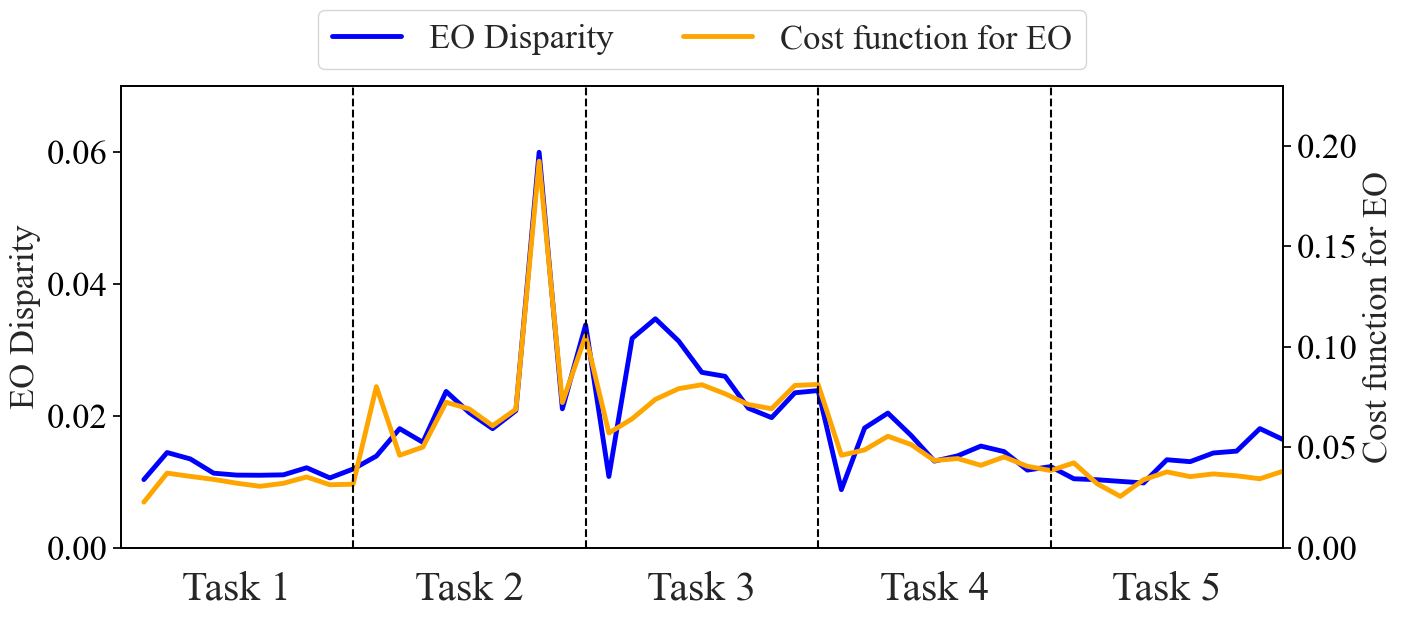

In [47]:
num_epochs = params['epochs_per_task']
num_tasks = params['num_tasks']

title = f""
draw_plot_loss([np.mean(x) for x in algorithm.disp], [np.mean(x) for x in algorithm.CELoss_disp], title, eo_range=None, ce_eo_range=None)

In [ ]:
# eo = [np.mean(x) for x in algorithm.disp]
# ce_eo = [np.mean(x) for x in algorithm.CELoss_disp]

In [34]:
eo = [0.010328576664488665,
 0.01442421229922659,
 0.013450307872742106,
 0.011296680139465675,
 0.011004464375562639,
 0.010983337022474693,
 0.011045756312998112,
 0.012118320847324426,
 0.01058247819938738,
 0.011926129907787807,
 0.013886012109777388,
 0.018045575136097596,
 0.015976637717051156,
 0.02368329131618241,
 0.020454566783502336,
 0.018041317660842916,
 0.020773679758663288,
 0.05991659433927297,
 0.021050882357901236,
 0.03376161048154813,
 0.010794538877514996,
 0.03172325723077339,
 0.0346908320385533,
 0.03131879454229817,
 0.0265750991875057,
 0.025970502490116787,
 0.021142800782446267,
 0.01971427558227105,
 0.023474517503287225,
 0.023814787408604654,
 0.008802898241798114,
 0.01814550128298991,
 0.020400224427668524,
 0.017011925798466512,
 0.013127944957448295,
 0.013925434907973544,
 0.01540207274715732,
 0.014564228079588654,
 0.011764754674747479,
 0.01229401547486782,
 0.010447876171095341,
 0.0103037942922858,
 0.010054410922266088,
 0.009817465435405705,
 0.013331918758082238,
 0.013042787302127316,
 0.014357657908999882,
 0.01463856656459654,
 0.01805101863455892,
 0.016382843408158182]

In [35]:
ce_eo = [0.022717888383265716,
 0.03716185199316392,
 0.0355154215841373,
 0.034031393545994194,
 0.03210708964334875,
 0.030583291921008372,
 0.03207683627165407,
 0.0352333540592657,
 0.031363120576840854,
 0.03161938894938245,
 0.08018841870692581,
 0.04603971011320271,
 0.050116095876920605,
 0.07242500344668953,
 0.06906910815334763,
 0.06073164832251743,
 0.06891882131324883,
 0.19245282873819425,
 0.07225739442692496,
 0.10550116787956784,
 0.057123183411938706,
 0.06418254949460853,
 0.07385487558996084,
 0.07919355241053828,
 0.08115197815782176,
 0.07664427129071803,
 0.07129669402091805,
 0.0692027606040583,
 0.08079348961050967,
 0.08129062495537775,
 0.046045206394850505,
 0.048710287707179306,
 0.05550079473486709,
 0.05136582624209438,
 0.04341113666673567,
 0.044405275875922426,
 0.04103247834365342,
 0.04521521159985633,
 0.040542106922077444,
 0.03843057457352357,
 0.04225957579644305,
 0.03185269437797735,
 0.025572244875845564,
 0.03386898330840484,
 0.03775996318539466,
 0.03540044091811125,
 0.03675953683571252,
 0.03580869272956985,
 0.0343430995756811,
 0.038122206444009266]